In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read the csv file
df=pd.read_csv('movie_data.csv',lineterminator='\n')

In [3]:
# Show dataframe
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


# Understanding the Problem

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [5]:
#checking for null values
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

In [6]:
#checking the datatype
df.dtypes

Release_Date          object
Title                 object
Overview              object
Popularity           float64
Vote_Count             int64
Vote_Average         float64
Original_Language     object
Genre                 object
Poster_Url            object
dtype: object

In [7]:
# check the genre column
df['Genre'].head()  # each genre is separated by comma and a whitespace

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [8]:
# check for duplicates 
df.duplicated().sum()

np.int64(0)

In [9]:
# checking the statistical values 
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


# Exploration Summary
* we have a dataframe consisting of 9827 rows and 9 columns.
* our dataset looks a bit tidy with no NaNs nor duplicated values.
* Release_Date column need to be casted into a date time and to extract only the year value.
* Overview,Original_Language and Poster-Url wouldn't be so useful during analysis, so we'll drop them.
* there is no noticiable outliers in the Popularity column.
* Vote_Average better to be categorized for proper analysis.
* Genre column has some comma separated values and white spaces that need to be handled and casted into category.

## Remove unncessary info

In [10]:
df.drop(axis=1,columns={'Overview','Original_Language','Poster_Url'},inplace=True)

In [11]:
#show dataframe
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

## Convert Release_Date column Datatype and extract year only

In [12]:
df['Release_Date']=pd.to_datetime(df['Release_Date'])
df.dtypes

Release_Date    datetime64[ns]
Title                   object
Popularity             float64
Vote_Count               int64
Vote_Average           float64
Genre                   object
dtype: object

In [13]:
df['Release_Year']=df['Release_Date'].dt.year

In [14]:
df.dtypes

Release_Date    datetime64[ns]
Title                   object
Popularity             float64
Vote_Count               int64
Vote_Average           float64
Genre                   object
Release_Year             int32
dtype: object

## Categorize the Voting_Average column into lables
* Popular
* Average
* Below Average
* Not Popular


we would cut the Vote_Average values and make 4 categories as above . To describe it more using categorization_col() function is provided below.

In [15]:
# general user defined function for categorization of any col
def categorize_col(df, col , label):
    
    edges=[ df[col].describe()['min'] ,
            df[col].describe()['25%'] ,
            df[col].describe()['50%'] ,
            df[col].describe()['75%'] ,
            df[col].describe()['max']
          ]

    df[col]= pd.cut(df[col], bins=edges, labels=labels ,duplicates='drop')
    return df

In [16]:
# creating the label
labels = ['not popular','below average','average','popular']

In [17]:
categorize_col( df, 'Vote_Average', labels)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction",2021
1,2022-03-01,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller",2022
2,2022-02-25,No Exit,2618.087,122,below average,Thriller,2022
3,2021-11-24,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy",2021
4,2021-12-22,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War",2021
...,...,...,...,...,...,...,...
9822,1973-10-15,Badlands,13.357,896,popular,"Drama, Crime",1973
9823,2020-10-01,Violent Delights,13.356,8,not popular,Horror,2020
9824,2016-05-06,The Offering,13.355,94,not popular,"Mystery, Thriller, Horror",2016
9825,2021-03-31,The United States vs. Billie Holiday,13.354,152,average,"Music, Drama, History",2021


In [18]:
# checking unique values and its count for the 'Vote_Average' columns

df['Vote_Average'].value_counts()

Vote_Average
not popular      2467
popular          2450
average          2412
below average    2398
Name: count, dtype: int64

In [19]:
#checking for  the nan values
df.isna().sum()

Release_Date      0
Title             0
Popularity        0
Vote_Count        0
Vote_Average    100
Genre             0
Release_Year      0
dtype: int64

In [20]:
# dropping nan values

df.dropna(inplace=True)

df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
Release_Year    0
dtype: int64

## Split the genres into a list and then explode the dataframe to have 1 genre per row for each column

In [21]:
# checking the type of single value og Genre column
type(df.loc[0,'Genre'])

str

In [22]:
df.loc[0,'Genre'].split(', ')

['Action', 'Adventure', 'Science Fiction']

In [23]:
# splitted the Genre column into list
df['Genre']= df['Genre'].str.split(', ')

In [24]:
# exolode the Genre column 
df=df.explode('Genre').reset_index(drop=True)

In [25]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,Action,2021
1,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,Adventure,2021
2,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction,2021
3,2022-03-01,The Batman,3827.658,1151,popular,Crime,2022
4,2022-03-01,The Batman,3827.658,1151,popular,Mystery,2022


In [26]:
# casting column into category

df['Genre'] = df['Genre'].astype('category')

df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Release_Date  25552 non-null  datetime64[ns]
 1   Title         25552 non-null  object        
 2   Popularity    25552 non-null  float64       
 3   Vote_Count    25552 non-null  int64         
 4   Vote_Average  25552 non-null  category      
 5   Genre         25552 non-null  category      
 6   Release_Year  25552 non-null  int32         
dtypes: category(2), datetime64[ns](1), float64(1), int32(1), int64(1), object(1)
memory usage: 949.2+ KB


In [28]:
df.nunique()

Release_Date    5846
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
Release_Year     100
dtype: int64

# Data Visualization

In [29]:
sns.set_style('whitegrid')

In [30]:
# what is the most frequent genre of movies released on Netflix
genre_freq=df['Genre'].value_counts()

genre_freq

Genre
Drama              3715
Comedy             3006
Action             2652
Thriller           2473
Adventure          1829
Romance            1461
Horror             1457
Animation          1426
Family             1405
Fantasy            1295
Science Fiction    1255
Crime              1235
Mystery             765
History             426
War                 307
Music               291
TV Movie            214
Documentary         203
Western             137
Name: count, dtype: int64

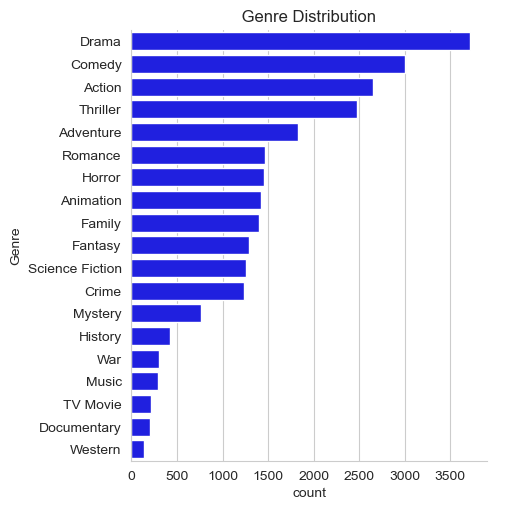

In [31]:
sns.catplot(data=df , y= 'Genre', kind= 'count' , color='blue',
            order= df['Genre'].value_counts().index)

plt.title( ' Genre Distribution ')
plt.show()

# which has the highest vote in vote_average columns

In [32]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,Action,2021
1,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,Adventure,2021
2,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction,2021
3,2022-03-01,The Batman,3827.658,1151,popular,Crime,2022
4,2022-03-01,The Batman,3827.658,1151,popular,Mystery,2022


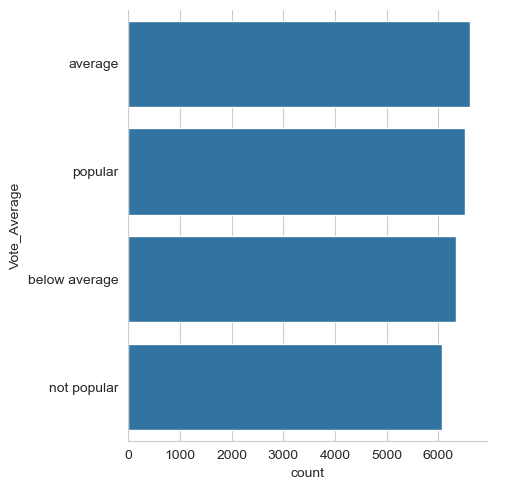

In [33]:
sns.catplot( y= 'Vote_Average', data= df, kind='count',
             order= df['Vote_Average'].value_counts().index)

# Which movie has got the highest popularity and whats its genre 

In [34]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,Action,2021
1,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,Adventure,2021
2,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction,2021
3,2022-03-01,The Batman,3827.658,1151,popular,Crime,2022
4,2022-03-01,The Batman,3827.658,1151,popular,Mystery,2022


In [49]:
df[df['Popularity'] == df['Popularity'].max() ]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,Action,2021
1,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,Adventure,2021
2,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction,2021
